In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn

import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
reset_random_seeds() 

df_train = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/train.csv")
df_test = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/test.csv")

split = len(df_train)

df = pd.concat([df_train,df_test])
input_col = 'text'
output_col = "label-fine"

X = df[input_col].values
Y = df[output_col].values

In [2]:
import spacy
import re
import time
from tqdm.auto import tqdm
from custom_tokenizer import BytePairEncodingTokenizer


# load tokenizer
tokenizer = BytePairEncodingTokenizer()
tokenizer.load_tokenizer('tokenizer.pkl')

nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

# text = """Only performs the fast regex string replacement."""

# 2. Pre-compile regex
HEX = re.compile(r'&#x[0-9A-Fa-f]+;')
DEC = re.compile(r'&#\d+;')
ASCII = re.compile(r'[^\x00-\x7F]+')
URL = re.compile(r'http\S+|www\S+')
ESCAPES = re.compile(r'[\n\t\r]+')

def clean_regex_only(text):
    """Only performs the fast regex string replacement."""
    x = str(text).lower()
    x = x.replace("&amp;","&").replace("<br />",'')
    x = HEX.sub('', x)
    x = DEC.sub("'", x)
    x = ASCII.sub("'", x)
    x = ESCAPES.sub(" ",x)
    x = URL.sub('LINK', x) 
    return x.strip()

def preprocess(text,nlp):
    clean_text = clean_regex_only(text)    
    sent = nlp.tokenizer(clean_text)
    sent = ' '.join([tok.text for tok in sent])
    return sent


X = [preprocess(sent,nlp) for sent in tqdm(X)]



  0%|          | 0/5952 [00:00<?, ?it/s]

In [3]:
tokenizer.maxlen = 256

X = [tokenizer.tokenize(x) for x in tqdm(X)]
X = np.array([tokenizer.add_padding(x) for x in tqdm(X)],np.int16)

  0%|          | 0/5952 [00:00<?, ?it/s]

  0%|          | 0/5952 [00:00<?, ?it/s]

In [4]:
# from sklearn.model_selection import train_test_split

# xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=1)

xtrain,xtest = X[:split],X[split:]
ytrain,ytest = Y[:split],Y[split:]

In [5]:
MAXLEN = tokenizer.maxlen
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 4
FF_UNITS = D_MODEL * 3
PEAK_LR = 1e-4
END_LR = 1e-6
INIT_LR = 1e-8
WARMUP_RATE = 0.05
BATCH = 8
EMB_DIM = 128
VOCAB_SIZE = len(tokenizer.i2w)

In [6]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
        self.norm_n_sim = None
    
    def forward(self,x,mask):
        mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
        mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
        mean_vec = mean_vec[:,torch.newaxis,:]
        mean_vec = mean_vec.transpose(1,2)
        score = torch.matmul(x,mean_vec).squeeze(-1)
        score = torch.where(mask,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        self.score = score
        return torch.sum(x * score,dim=1)
    
    
class AttentionPool(nn.Module):
    
    def __init__(self,dim=256,temp=1):
        super().__init__()
        self.dim = dim 
        self.score = None
        self.w = nn.Linear(dim,1,bias=False)
        self.temp = temp
        
    def forward(self,x,mask=None):
        attn = self.w(x)
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask,-1e8,attn)
        attn = torch.softmax(attn/self.temp,axis=1)
        self.score = attn
        x = x * attn
        return x.sum(1)
    


In [7]:
class FactorizeEmbeddingLayer(nn.Module):

    def __init__(self,vocab_size,d_model,maxlen):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.maxlen = maxlen

        self.emb = nn.Embedding(self.vocab_size,self.d_model // 2)
        self.fact_layer = nn.Linear(self.d_model // 2, self.d_model)
        self.pos_encoding = nn.Parameter(self._positional_encoding(),requires_grad=False)

    def _positional_encoding(self):
        pos = np.zeros((self.maxlen, self.d_model), dtype=np.float32)
        for p in range(self.maxlen):
            for i in range(self.d_model):
                exponent = 2 * (i // 2) / self.d_model
                angle = p / (10000 ** exponent)

                if i % 2 == 0:
                    pos[p, i] = np.sin(angle)
                else:
                    pos[p, i] = np.cos(angle)
        return torch.tensor(pos,dtype=torch.float32)

    def forward(self,x):
        mask = x == 0
        x = self.fact_layer(self.emb(x)) + self.pos_encoding[:x.shape[1], :].unsqueeze(0)
        return x,mask

In [8]:
from encoder_decoder import EncoderLayer
from torchinfo import summary


class Classifier(nn.Module):

    def __init__(self,d_model,vocab_size,maxlen,n_heads,ff_units,n_layers,pool_type='geometric_pool',n_classes=1):
        super().__init__()
        
        self.n_layers = n_layers
        self.pool_type = pool_type
        
        self.emb = FactorizeEmbeddingLayer(vocab_size,d_model,maxlen)
        self.encoder = EncoderLayer(d_model,n_heads,ff_units)
        self.pooling = nn.ModuleDict({"attn_pool":AttentionPool(d_model),
                                      "geometric_pool":GeometricPooling()})
        self.out = nn.Linear(d_model,n_classes)
        

    def forward(self,i,return_pool=False,return_final_seq=False):

        x,mask = self.emb(i)

        for _ in range(self.n_layers):
            x = self.encoder([x,mask])
            
        if return_final_seq:
            return x * ~mask[:,:,torch.newaxis]

        x = self.pooling[self.pool_type](x,mask=mask)
        
        if return_pool:
            return x
        
        x = self.out(x)

        return x


reset_random_seeds()

n_classes = len(np.unique(ytrain))

device = torch.device("cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS)

model = model.to(device)

inp = torch.randint(0,VOCAB_SIZE,(BATCH,MAXLEN))
print(summary(model,input_data=inp))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)




Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [8, 1]                    --
├─FactorizeEmbeddingLayer: 1-1           [8, 256, 256]             65,536
│    └─Embedding: 2-1                    [8, 256, 128]             2,565,248
│    └─Linear: 2-2                       [8, 256, 256]             33,024
├─EncoderLayer: 1-2                      [8, 256, 256]             --
│    └─MultiHeadAttention: 2-3           [8, 256, 256]             --
│    │    └─Linear: 3-1                  [8, 256, 256]             65,536
│    │    └─Linear: 3-2                  [8, 256, 256]             65,536
│    │    └─Linear: 3-3                  [8, 256, 256]             65,536
│    │    └─Dropout: 3-4                 [8, 8, 256, 256]          --
│    │    └─Linear: 3-5                  [8, 256, 256]             65,792
│    │    └─Dropout: 3-6                 [8, 256, 256]             --
│    └─LayerNorm: 2-4                    [8, 256, 256]

In [9]:
from torch.utils.data import TensorDataset, DataLoader
import torch_optimizer

def create_tensor_data(x,y,batch,shuffle=True):
    
    x_ = torch.tensor(x,dtype=torch.int32,device=device)
    y_ = torch.tensor(y,dtype=torch.int32,device=device)
    data = TensorDataset(x_,y_)
    data = DataLoader(data,batch_size=batch,shuffle=shuffle)
    return data

train = create_tensor_data(xtrain,ytrain,BATCH)
test = create_tensor_data(xtest,ytest,BATCH * 2,shuffle=False)

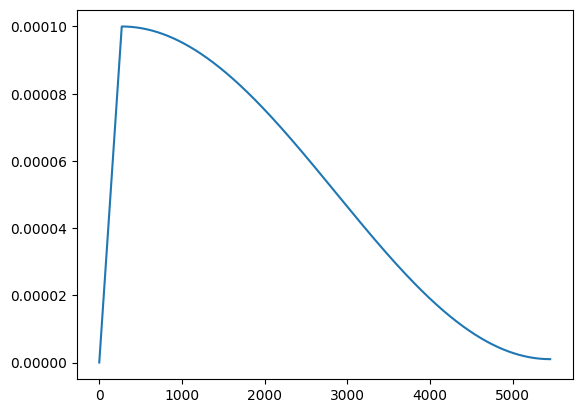

In [10]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

EPOCHS = 8
train_steps = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(train_steps,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,train_steps+1)])

In [11]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS=10,file='saved_weights.pt'):
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            x,y = batch
            y = y.long()
            pred = model(x)
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)

        print(f'Train Loss = {loss}')

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(test):

                x,y = batch
                y = y.long()
                pred = model(x)
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()

        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('-------------------------------------')
        print()

In [12]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes,pool_type='attn_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='attn_pool.pt')


1/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 2.4092
Val Loss = 1.7219
--weights saved
-------------------------------------

2/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 1.4647
Val Loss = 1.4196
--weights saved
-------------------------------------

3/8


...

Train Loss = 0.5794
Val Loss = 1.1459
--weights saved
-------------------------------------

7/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5039
Val Loss = 1.1237
--weights saved
-------------------------------------

8/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.468
Val Loss = 1.1236
--weights saved
-------------------------------------



In [13]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes,pool_type='geometric_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='geometric_pool.pt')

1/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 2.4572
Val Loss = 1.7652
--weights saved
-------------------------------------

2/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 1.5134
Val Loss = 1.454
--weights saved
-------------------------------------

3/8


...

Train Loss = 0.6039
Val Loss = 1.1615
--weights saved
-------------------------------------

7/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5273
Val Loss = 1.1337
--weights saved
-------------------------------------

8/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.492
Val Loss = 1.1319
--weights saved
-------------------------------------



In [14]:
def load_model(pool_type):
    model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                       n_classes=n_classes,pool_type=pool_type)
    model = model.to('cuda')
    state_dict = torch.load(f'{pool_type}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

model1 = load_model('attn_pool')
model2 = load_model('geometric_pool')

In [15]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
from tqdm import tqdm
import torch

def get_pooling_scores(seq):
    model1.eval()
    model2.eval()
    
    with torch.no_grad():
        model1(seq)
        model2(seq)

        # Shape: [batch_size, seq_len]
        attn_probs = model1.pooling['attn_pool'].score.cpu().numpy()[:,:,0]
        geo_probs = model2.pooling['geometric_pool'].score.cpu().numpy()[:,:,0]
        
        # Bring input seq to CPU to check for padding safely
        seq_np = seq.cpu().numpy()
        
    batch_attn = []
    batch_geo = []
    
    # Iterate through each sequence in the batch individually
    for i in range(seq_np.shape[0]):
        # Safer masking: Use the input tokens to find padding, assuming padding ID is 0
        idx = np.where(seq_np[i] > 0)
        
        # Append only the valid tokens for THIS specific sentence
        batch_attn.append(attn_probs[i][idx])
        batch_geo.append(geo_probs[i][idx])
        
    return batch_attn, batch_geo


# --- Test Loop ---
scores = {'attn': [], 'geo': []}

for x, _ in test:
    # Move x to GPU if your test loop doesn't do it automatically
    # x = x.to('cuda')
    
    attn, geo = get_pooling_scores(x)
    
    # Because attn and geo are now lists of arrays, .extend() correctly 
    # adds arrays (sequences) to the scores lists instead of individual floats
    scores['attn'].extend(attn)
    scores['geo'].extend(geo)

# --- Correlation Calculation ---
s_corr = 0
p_corr = 0
count = 0  # Must start at 0

for s1, s2 in tqdm(zip(scores['attn'], scores['geo']), total=len(scores['attn'])):
    # Spearman requires at least 2 data points (tokens) to rank
    if len(s1) > 1:
        sm = spearmanr(s1, s2).statistic
        ps = pearsonr(s1, s2).statistic
        # Ignore NaN values (happens if a sequence has perfectly uniform weights, causing 0 variance)
        if not np.isnan(sm) and not np.isnan(ps):
            s_corr += sm
            p_corr += ps
            count += 1

print(f"\nEvaluated {count} valid sequences.")
print(f"Average Spearman Correlation: {s_corr / count:.4f}")
print(f"Average Pearson Correlation: {p_corr / count:.4f}")

100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1592.86it/s]


Evaluated 500 valid sequences.
Average Spearman Correlation: 0.3764
Average Pearson Correlation: 0.0564


In [16]:
import matplotlib.pyplot as plt
import seaborn as sb


def get_weighted_probs(seq):
    
    seq = torch.tensor(seq,dtype=torch.int32)
    seq = seq.to('cuda')
    seq = seq[torch.newaxis,:]
    
    model1.eval()
    model2.eval()
    
    with torch.no_grad():
    
        p1 = model1(seq)
        p2 = model2(seq)

        attn_probs = model1.pooling['attn_pool'].score.detach().cpu().numpy().reshape(-1)
        geo_probs = model2.pooling['geometric_pool'].score.detach().cpu().numpy().reshape(-1)

    seq = seq.cpu().numpy()
    text = [tokenizer.i2w[t] for t in seq[0] if t > 0]

    attn_plot = {w:p for w,p in zip(text,attn_probs)}
    geo_plot = {w:p for w,p in zip(text,geo_probs)}

    print(' '.join([x for x in text]))

    fig,ax = plt.subplots(1,2,figsize=(12,8),sharey=True)

    sb.barplot(geo_plot,orient='h',ax=ax[0])
    sb.barplot(attn_plot,orient='h',ax=ax[1])

    ax[0].set_title('geometric_pool')
    ax[1].set_title('attn_pool')

    plt.tight_layout()

    p1,p2 = torch.sigmoid(p1[0][0]),torch.sigmoid(p2[0][0])
    p1 = p1.detach().cpu().numpy()
    p2 = p2.detach().cpu().numpy()
    return p1,p2

In [17]:
import seaborn


i = np.random.randint(0,len(xtest))
# i = 938
seq = xtest[i]

def plot_norm_n_sim(seq):
    # Ensure seq is a numpy array in case a list is passed
    seq_arr = np.array(seq)
    text = [tokenizer.i2w[t] for t in seq_arr if t > 0]
    idx = np.where(seq_arr > 0)
    
    # 1. Set model to evaluation mode (disables Dropout/BatchNorm shifts)
    model2.eval()
    
    # 2. Disable gradients to save memory and ensure deterministic output
    with torch.no_grad():
        seq_tensor = torch.tensor(seq_arr, dtype=torch.int32).to('cuda')
        seq_tensor = seq_tensor[torch.newaxis, :]
        
        # Get embeddings
        out_seq = model2(seq_tensor, return_final_seq=True)[0]
        
        # Calculate Norm and Similarity
        norm = torch.norm(out_seq, dim=-1)
        gv = torch.sum(out_seq, dim=0)
        gv = gv / torch.norm(gv)
        gv = gv.unsqueeze(0)
        
        sim = torch.cosine_similarity(gv, out_seq)
        
        # Filter padding tokens using idx
        sim, norm = sim[idx], norm[idx]
        
        # detach() is no longer needed because of torch.no_grad()
        sim = sim.cpu().numpy()
        norm = norm.cpu().numpy()

    tmp_data = {'sim': sim, 'norm': norm, 'tokens': text}
    tmp_data = pd.DataFrame(tmp_data)

    plt.figure(figsize=(8, 5))
    ax = sb.scatterplot(data=tmp_data, x='sim', y='norm')
    

    for i in range(tmp_data.shape[0]):
        ax.text(
            x=tmp_data.sim[i],
            y=tmp_data.norm[i],
            s=tmp_data.tokens[i],
            fontdict=dict(color="black", size=10),
        )

    plt.show()
#     print(' '.join(text))
    
    


<cls> --what --is --the --life --expect ancy --for --cri ckets --? <sep>
attn_pool : 0.3218 || geometric_pool : 0.3799


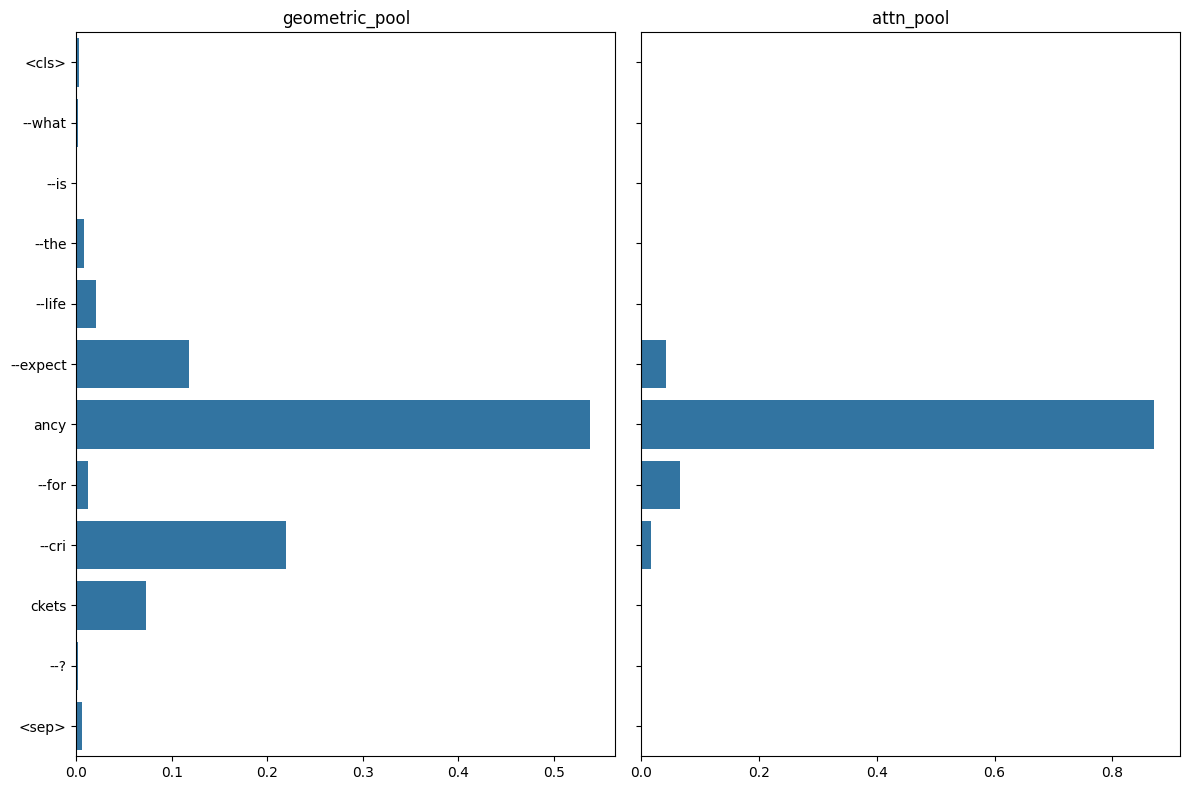

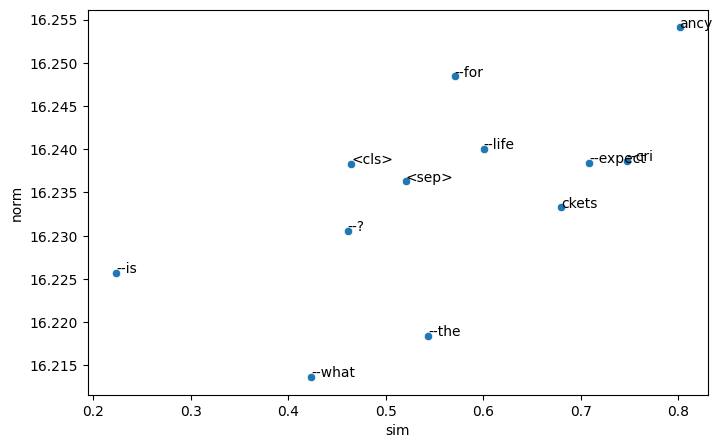

In [18]:
i = np.random.randint(0,len(xtest))
seq = xtest[i]

p1,p2 = get_weighted_probs(seq)
print(f"attn_pool : {p1:.4f} || geometric_pool : {p2:.4f}")

plot_norm_n_sim(seq)

<cls> --what --year --did --the --tit ani c --start --on --its --journey --? <sep>
attn_pool : 0.4249 || geometric_pool : 0.7018


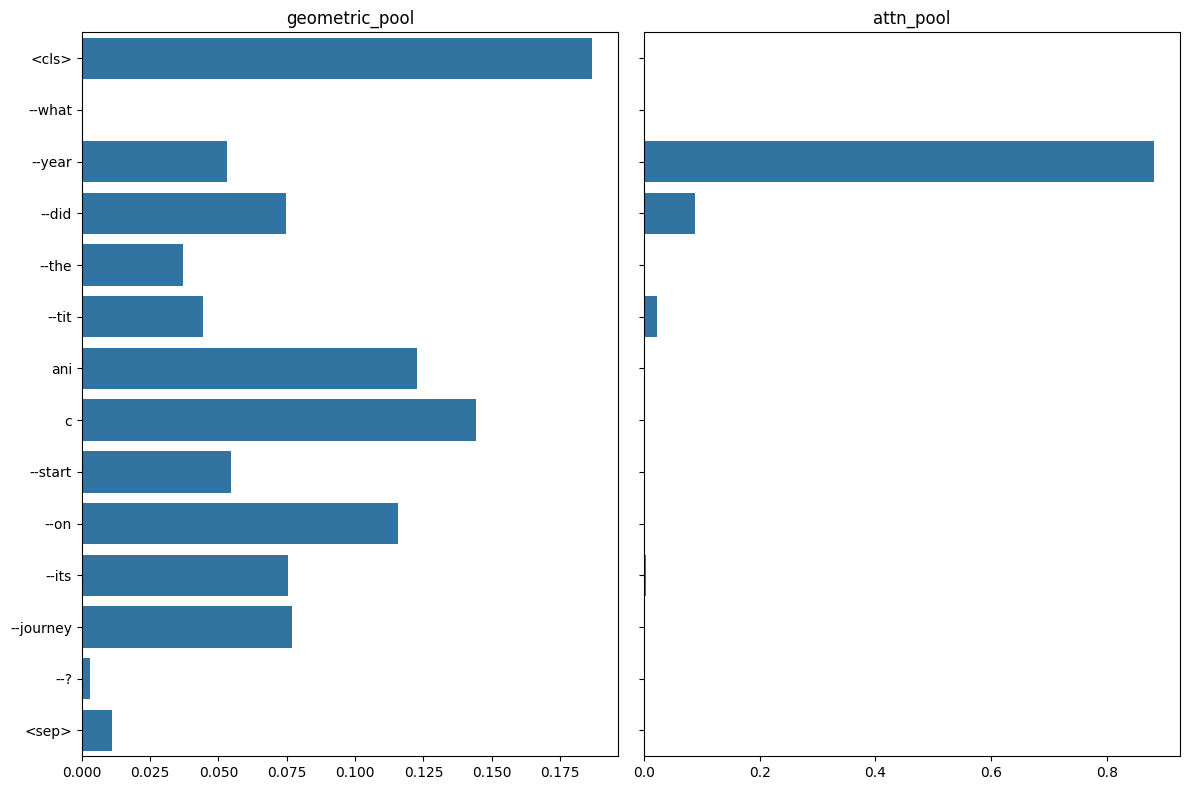

In [19]:
i = np.random.randint(0,len(xtest))
seq = xtest[i]
p1,p2 = get_weighted_probs(seq)
print(f"attn_pool : {p1:.4f} || geometric_pool : {p2:.4f}")

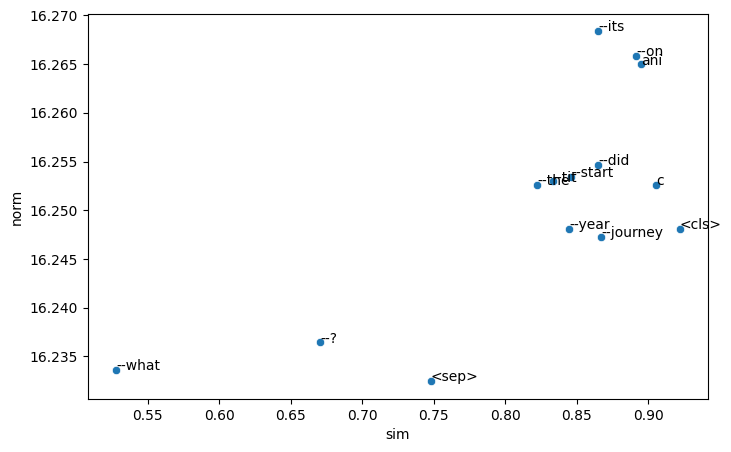

<cls> --what --year --did --the --tit ani c --start --on --its --journey --? <sep>


In [20]:
import seaborn


# i = np.random.randint(0,len(xtest))
# i = 938
seq = xtest[i]

def plot_norm_n_sim(seq):
    # Ensure seq is a numpy array in case a list is passed
    seq_arr = np.array(seq)
    text = [tokenizer.i2w[t] for t in seq_arr if t > 0]
    idx = np.where(seq_arr > 0)
    
    # 1. Set model to evaluation mode (disables Dropout/BatchNorm shifts)
    model2.eval()
    
    # 2. Disable gradients to save memory and ensure deterministic output
    with torch.no_grad():
        seq_tensor = torch.tensor(seq_arr, dtype=torch.int32).to('cuda')
        seq_tensor = seq_tensor[torch.newaxis, :]
        
        # Get embeddings
        out_seq = model2(seq_tensor, return_final_seq=True)[0]
        
        # Calculate Norm and Similarity
        norm = torch.norm(out_seq, dim=-1)
        gv = torch.sum(out_seq, dim=0)
        gv = gv / torch.norm(gv)
        gv = gv.unsqueeze(0)
        
        sim = torch.cosine_similarity(gv, out_seq)
        
        # Filter padding tokens using idx
        sim, norm = sim[idx], norm[idx]
        
        # detach() is no longer needed because of torch.no_grad()
        sim = sim.cpu().numpy()
        norm = norm.cpu().numpy()

    tmp_data = {'sim': sim, 'norm': norm, 'tokens': text}
    tmp_data = pd.DataFrame(tmp_data)

    plt.figure(figsize=(8, 5))
    ax = sb.scatterplot(data=tmp_data, x='sim', y='norm')
    

    for i in range(tmp_data.shape[0]):
        ax.text(
            x=tmp_data.sim[i],
            y=tmp_data.norm[i],
            s=tmp_data.tokens[i],
            fontdict=dict(color="black", size=10),
        )

    plt.show()
    print(' '.join(text))
    
    
plot_norm_n_sim(seq)

In [21]:
vec_norms = []

model2.eval()

with torch.no_grad():

    for x, _ in test:
        vec_seq = model2(x,return_final_seq=True)
        norm = torch.norm(vec_seq,dim=-1)
        idx = torch.where(norm>0)
        norm = norm[idx]
        norm = norm.detach().cpu().numpy()
        vec_norms.extend(norm)
    
    
vec_norms = np.array(vec_norms)
vec_norms.std()
    
    
    


np.float32(0.01626359)